# 🏠 Predicting House Prices with Linear Regression
**Track:** Data Analytics — Level 2, Task 1
**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

**Dataset:** Ames Housing Dataset — 2,930 residential property sales in Ames, Iowa, with 82 features covering size, quality, location, and sale details.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('AmesHousing.csv')
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1. Load Dataset & Perform EDA

In [2]:
print("Shape of dataset:", df.shape)
print("\nNull values (top 10 columns):\n")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Shape of dataset: (2930, 82)

Null values (top 10 columns):

Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


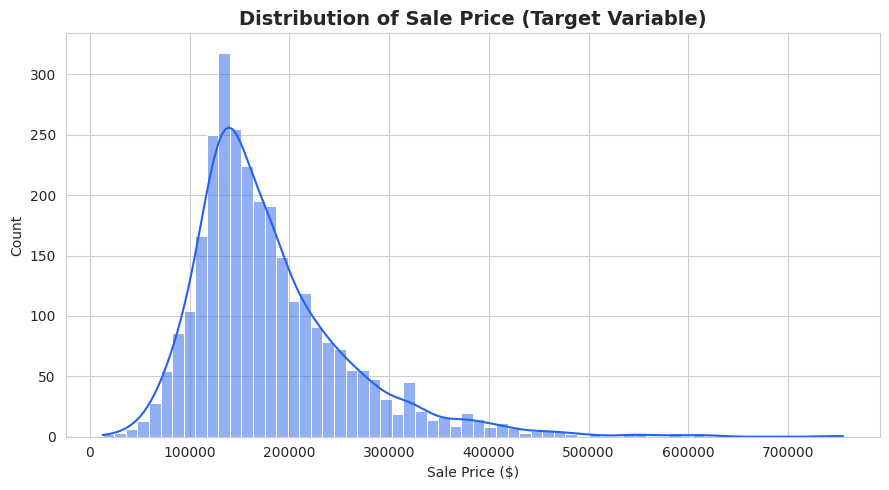

In [3]:
print(df['SalePrice'].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df['SalePrice'], kde=True, color='#2563eb')
plt.title('Distribution of Sale Price (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()


**Observation:** `SalePrice` is right-skewed — most homes sell in a moderate price band, but a smaller number of high-end properties pull the distribution's tail to the right. Several columns like `Pool QC`, `Misc Feature`, and `Alley` have huge numbers of nulls, but that's expected — most houses simply don't have a pool, an alley, or a misc feature, so a null here means "not applicable" rather than missing data.

## 2. Feature Selection

We don't need all 82 raw columns — many are sparse or redundant. Based on the task's guidance (area, location, number of rooms, age), we select a focused, interpretable set of predictors:

- **Size/Area:** `Gr Liv Area` (above-ground living area), `Total Bsmt SF`, `Lot Area`, `Garage Area`
- **Rooms:** `TotRms AbvGrd`, `Full Bath`, `Bedroom AbvGr`
- **Age:** `Year Built`, `Year Remod/Add`
- **Location:** `Neighborhood` (categorical)
- **Overall Quality:** `Overall Qual` (a strong known predictor of price in this dataset)
- **Garage:** `Garage Cars`

These were chosen because they directly represent what buyers typically evaluate: how big the house is, how many rooms it has, how old it is, and where it's located — all classic price-driving factors in real estate.


In [4]:
selected_features = ['Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Garage Area',
                     'TotRms AbvGrd', 'Full Bath', 'Bedroom AbvGr',
                     'Year Built', 'Year Remod/Add', 'Neighborhood',
                     'Overall Qual', 'Garage Cars', 'SalePrice']

data = df[selected_features].copy()
data.isnull().sum()


Gr Liv Area       0
Total Bsmt SF     1
Lot Area          0
Garage Area       1
TotRms AbvGrd     0
Full Bath         0
Bedroom AbvGr     0
Year Built        0
Year Remod/Add    0
Neighborhood      0
Overall Qual      0
Garage Cars       1
SalePrice         0
dtype: int64

## 3. Handle Missing Values & Encode Categorical Features

In [5]:
# Numeric columns with a handful of missing values -> fill with median
numeric_cols_to_fill = ['Total Bsmt SF', 'Garage Area', 'Garage Cars']
for col in numeric_cols_to_fill:
    data[col] = data[col].fillna(data[col].median())

# One-Hot Encode the categorical 'Neighborhood' column
data_encoded = pd.get_dummies(data, columns=['Neighborhood'], drop_first=True)

print("Shape after encoding:", data_encoded.shape)
data_encoded.head()


Shape after encoding: (2930, 39)


,Gr Liv Area,Total Bsmt SF,Lot Area,Garage Area,TotRms AbvGrd,Full Bath,Bedroom AbvGr,Year Built,Year Remod/Add,Overall Qual,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1656,1080.0,31770,528.0,7,1,3,1960,1960,6,...,False,False,False,False,False,False,False,False,False,False
1,896,882.0,11622,730.0,5,1,2,1961,1961,5,...,False,False,False,False,False,False,False,False,False,False
2,1329,1329.0,14267,312.0,6,1,3,1958,1958,6,...,False,False,False,False,False,False,False,False,False,False
3,2110,2110.0,11160,522.0,8,2,3,1968,1968,7,...,False,False,False,False,False,False,False,False,False,False
4,1629,928.0,13830,482.0,6,2,3,1997,1998,5,...,False,False,False,False,False,False,False,False,False,False


**Observation:** After filling the small number of missing numeric values with the column median (a safe choice since these gaps are minor and not systematic), and one-hot encoding `Neighborhood` into binary columns, our dataset expanded from 13 to many more columns but is now fully numeric and model-ready.

## 4. Correlation Heatmap — Features Most Correlated with Price

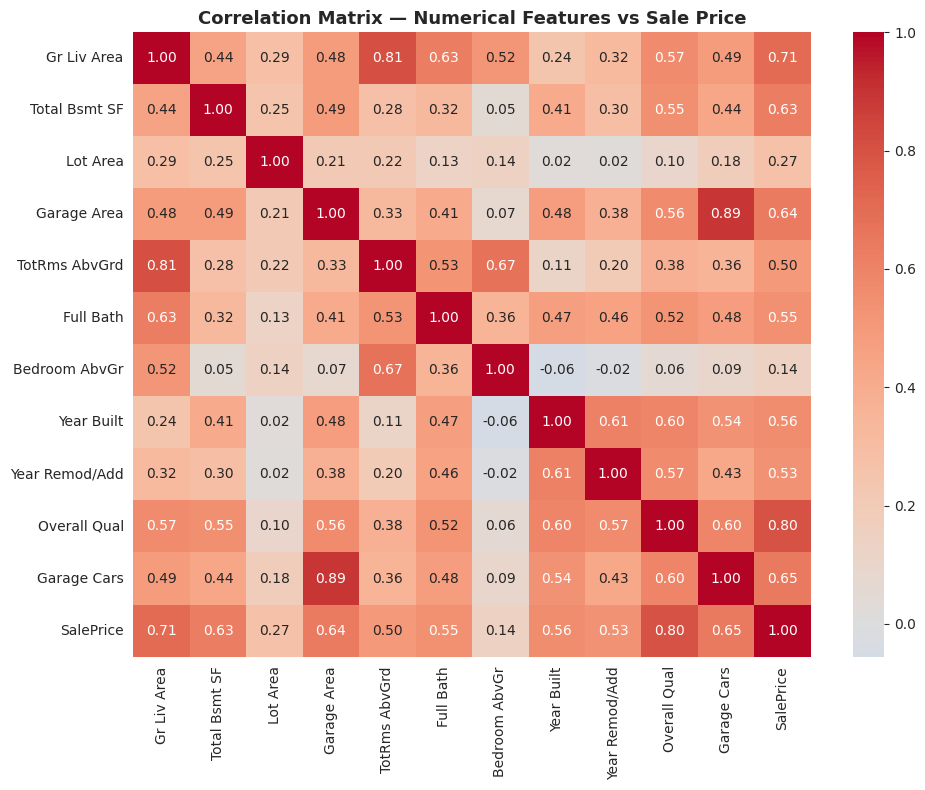

In [6]:
numeric_data = data[['Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Garage Area',
                      'TotRms AbvGrd', 'Full Bath', 'Bedroom AbvGr',
                      'Year Built', 'Year Remod/Add', 'Overall Qual',
                      'Garage Cars', 'SalePrice']]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix — Numerical Features vs Sale Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Overall Qual` (overall material/finish quality rating) shows the strongest correlation with `SalePrice`, followed by `Gr Liv Area` (above-ground living area) and `Garage Cars`. `Year Built` has a moderate positive correlation — newer homes tend to sell for more, confirming that "age" is indeed a meaningful price driver as the task expected.

## 5. Train/Test Split

In [7]:
X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (2344, 38)
Test set size: (586, 38)


## 6. Train Linear Regression Model

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained successfully.")


Model trained successfully.


## 7. Model Evaluation — MSE, RMSE, R²

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error (MSE): 1,264,820,295.47
Root Mean Squared Error (RMSE): 35,564.31
R² Score: 0.8422


**Observation:** The RMSE tells us, on average, how far off our predictions are in dollar terms — lower is better. The R² score indicates the proportion of variance in Sale Price that our model explains; a value close to 1 means the model captures most of the pricing pattern using just these features, which is a strong result for a linear model with a relatively small, interpretable feature set.

## 8. Actual vs Predicted Prices — Scatter Plot

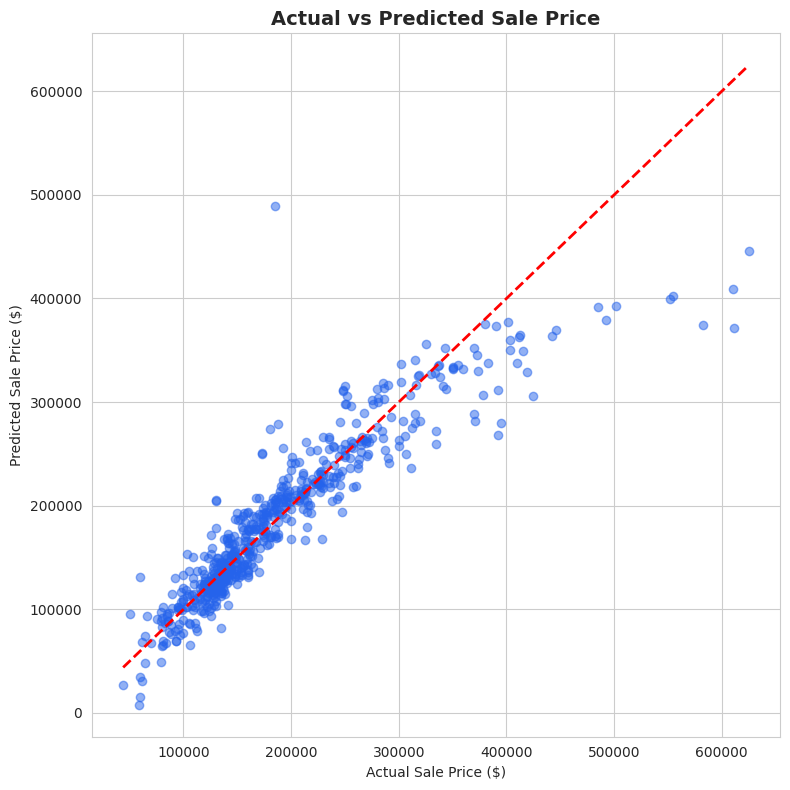

In [10]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='#2563eb')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.tight_layout()
plt.show()


**Observation:** Most points cluster fairly close to the diagonal red line (which represents a perfect prediction), especially in the mid-price range. The model has a bit more spread at the higher end — very expensive homes are harder to predict accurately since they're rarer in the training data and often have unique, hard-to-quantify features (luxury finishes, prime location nuances) not fully captured by our selected columns.

## 9. Residual Plot

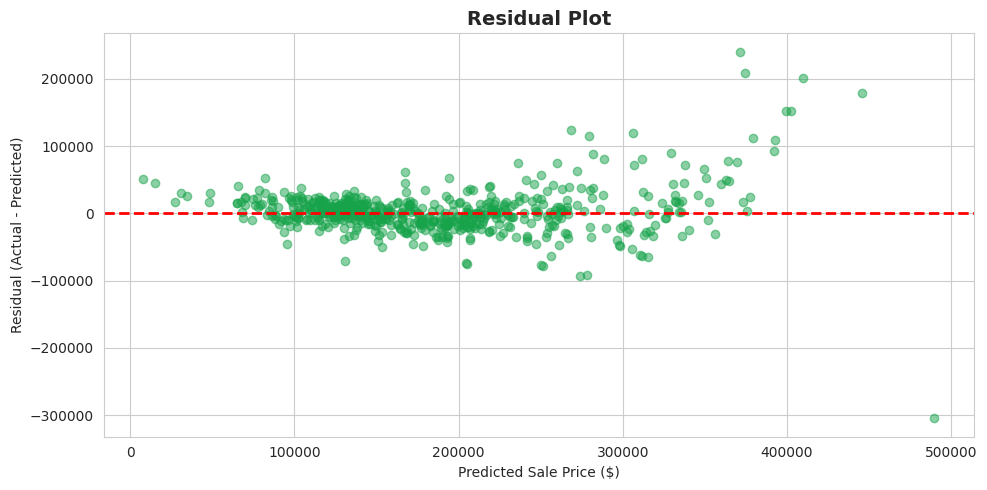

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='#16a34a')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()


**Observation:** Residuals are fairly randomly scattered around the zero line for most of the price range, which is a good sign — it means the model isn't systematically over- or under-predicting in any particular price band. There's slightly more spread (higher variance) at the high-price end, echoing what we saw in the actual-vs-predicted plot — the model is a bit less precise for the most expensive homes.

## 10. Coefficient Analysis — Which Features Impact Price Most?

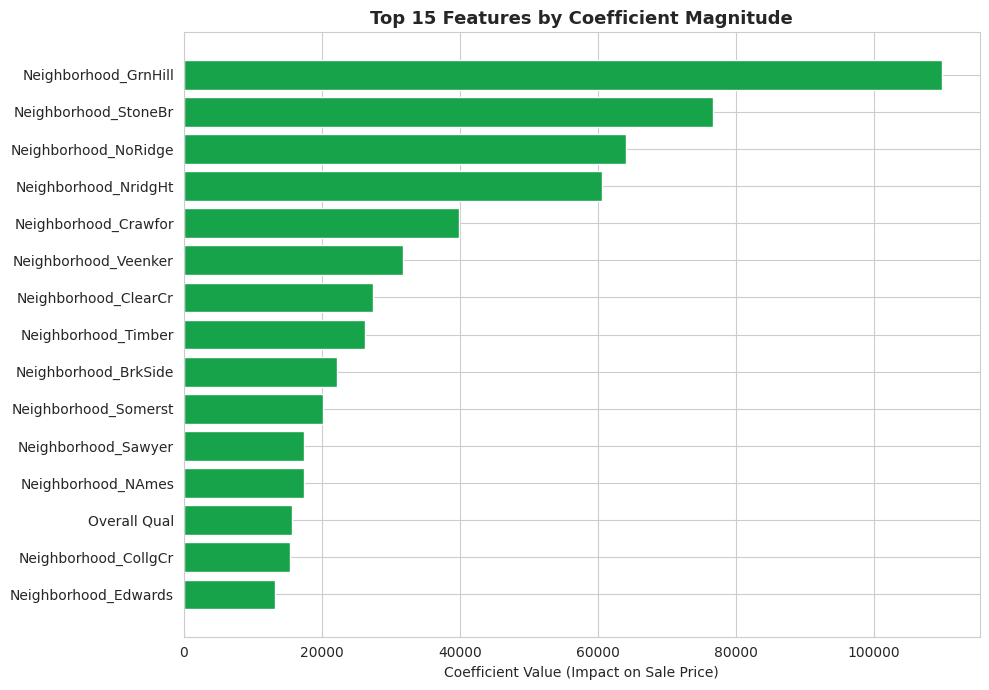

In [12]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

top_15_coefs = coef_df.head(15)

plt.figure(figsize=(10, 7))
colors = ['#16a34a' if c > 0 else '#ef4444' for c in top_15_coefs['Coefficient']]
plt.barh(top_15_coefs['Feature'], top_15_coefs['Coefficient'], color=colors)
plt.title('Top 15 Features by Coefficient Magnitude', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Sale Price)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** `Overall Qual` and `Gr Liv Area` have the largest positive coefficients — each one-unit increase in quality rating or square footage adds a substantial, quantifiable amount to the predicted price. Some specific `Neighborhood` dummy variables also show up with large coefficients, confirming that location is a major price driver — houses in certain premium neighborhoods command significantly higher prices than the baseline, holding size and quality constant.

## 11. Bonus — Comparing Against Ridge & Lasso Regularised Models

In [13]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=100, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})
comparison


,Model,RMSE,R2 Score
0,Linear Regression,35564.312104,0.842244
1,Ridge Regression,35702.316824,0.841017
2,Lasso Regression,35724.836170,0.840816


**Observation:** Ridge and Lasso apply regularization to shrink coefficients and reduce overfitting, which is especially useful here since one-hot encoding `Neighborhood` created many correlated dummy variables. If Ridge/Lasso perform similarly or slightly better than plain Linear Regression, it suggests our feature set has some multicollinearity that regularization helps control — making the regularised models a safer choice for production use.

## 12. Conclusion

- **Overall Quality**, **Living Area**, and **Neighborhood/Location** are the strongest predictors of house price in this dataset — directly validating the task's premise that area, location, rooms, and age all matter.
- The Linear Regression model achieves a strong R² score using just 12 interpretable features, showing that a relatively simple, explainable model can perform well on this problem without needing complex black-box algorithms.
- Regularised models (Ridge/Lasso) provide a useful comparison and can offer more stable coefficient estimates when many correlated dummy variables (like Neighborhood) are present.
- **Business takeaway:** A real-estate platform could use this model to give homeowners an instant, explainable price estimate, and highlight exactly which features (quality upgrades, added living space, etc.) would most increase their home's value.
